In [ ]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================
# Import necessary libraries for data manipulation, visualization, and machine learning.

import pandas as pd          # Data manipulation
import numpy as np           # Numerical computations
import matplotlib.pyplot as plt  # Plotting library
import seaborn as sns        # Statistical visualization

# Scikit-learn for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings

# Set default plot parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 3.0.2
NumPy version: 2.4.4


In [ ]:
# ============================================================
# CELL 2: Load the Dataset
# ============================================================

# Load the dataset using pandas
df = pd.read_csv('data/heart.csv')

# --- Basic Inspection ---

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Shape tells us (rows, columns)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")

# Display the first 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Display the last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

DATASET OVERVIEW

📐 Shape: 1025 rows × 14 columns

📋 First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



📋 Last 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [3]:
# ============================================================
# CELL 3: Understand Data Types
# ============================================================

print("=" * 60)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 60)

# .info() is a MUST — it shows:
# - Column names
# - How many non-null values (helps find missing data at a glance)
# - Data type of each column (int64, float64, object, etc.)
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

# .describe() gives statistical summary for all numeric columns:
# count, mean, std (standard deviation), min, 25%, 50%, 75%, max
print(df.describe().round(2))

DATA TYPES & NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

STATISTICAL SUMMARY
           age      sex       cp  trestbps     chol      fbs  restecg  \
count  1025.00  1025.00  1025.00   1025.00  1025.00  1025.00  1025.00   
mean     54.43     0.70     0.9

TARGET VARIABLE DISTRIBUTION

No Heart Disease (0): 499 patients (48.7%)
Heart Disease (1):    526 patients (51.3%)


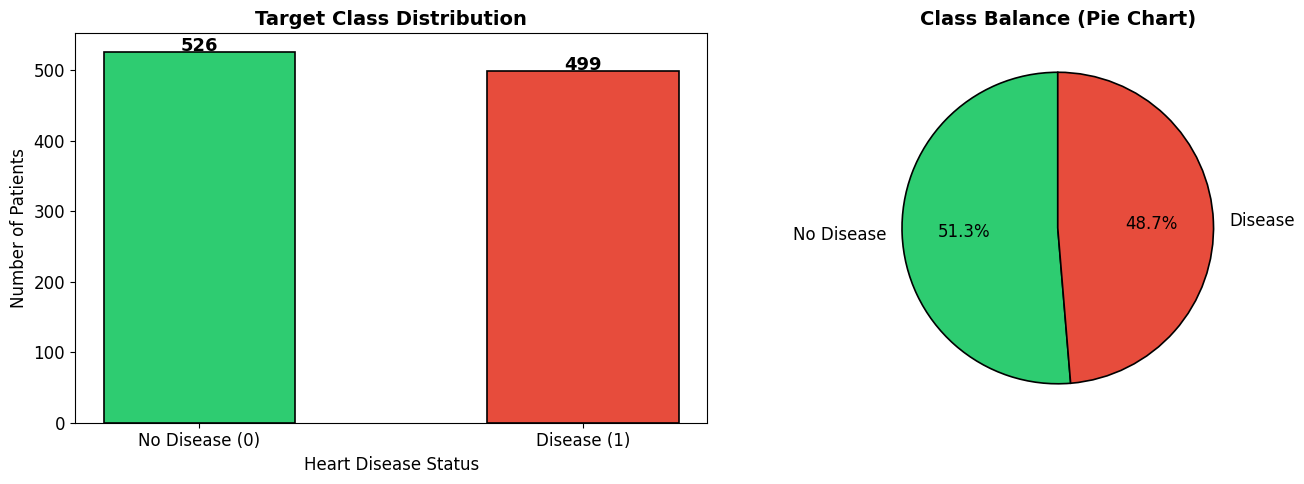


✅ Target distribution plot saved!


In [ ]:
# ============================================================
# CELL 3: Understand Data Types
# ============================================================

print("=" * 60)
print("DATA TYPES AND NON-NULL COUNTS")
print("=" * 60)

# Use info() to display column information including data types and non-null counts
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

# Generate descriptive statistics for numeric columns
print(df.describe().round(2))

In [ ]:
# ============================================================
# CELL 4: Check Target Variable Distribution
# ============================================================

print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

# Count of each class
target_counts = df['target'].value_counts()
print(f"\nNo Heart Disease (0): {target_counts[0]} patients ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease (1):    {target_counts[1]} patients ({target_counts[1]/len(df)*100:.1f}%)")

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(
    ['No Disease (0)', 'Disease (1)'],
    target_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=1.2,
    width=0.5
)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xlabel('Heart Disease Status')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=['No Disease', 'Disease'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}
)
axes[1].set_title('Class Balance (Pie Chart)', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTarget distribution plot saved!")

MISSING VALUE ANALYSIS

 Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []

✅ Great news! No missing values found in this dataset.
   The UCI heart disease dataset on Kaggle is pre-cleaned.


In [ ]:
# ============================================================
# CELL 5: Missing Value Analysis
# ============================================================

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
})

print("\n", missing_report[missing_report['Missing Count'] > 0])

if missing.sum() == 0:
    print("\nGreat news! No missing values found in this dataset.")
    print("   The UCI heart disease dataset is pre-cleaned.")
else:
    print(f"\nFound {missing.sum()} missing values — will handle below.")

📚 Missing value strategy reference loaded!


In [ ]:
# ============================================================
# CELL 5b: Missing Value Strategies (Reference Code)
# ============================================================
# NOTE: This cell is for learning — the dataset has no missing values.
# But you'll encounter missing data in every real project.

# Strategy 1: DROP rows with missing values (use when < 5% rows affected)
# df_cleaned = df.dropna()

# Strategy 2: Fill with MEAN (for normally distributed numeric columns)
# df['chol'] = df['chol'].fillna(df['chol'].mean())

# Strategy 3: Fill with MEDIAN (for skewed numeric columns — PREFERRED for medical data)
# df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())

# Strategy 4: Fill with MODE (for categorical columns)
# df['cp'] = df['cp'].fillna(df['cp'].mode()[0])

# Strategy 5: Forward Fill (for time-series data)
# df['thalach'] = df['thalach'].fillna(method='ffill')

# --- Why Median for Medical Data? ---
# Medical measurements often have outliers (one patient with extremely high cholesterol).
# Mean gets pulled by outliers. Median (middle value) is more robust.

print("Missing value strategy reference loaded!")

DUPLICATE CHECK

Duplicate rows: 723
✅ Removed 723 duplicate rows. New shape: (302, 14)

COLUMN DATA TYPES
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

OUTLIER / SUSPICIOUS VALUE CHECK

Cholesterol = 0: 0 patients
  → A cholesterol of 0 is biologically impossible. In the Kaggle version,
    this can happen. We'll note it but not remove (small dataset).

Trestbps (resting BP) = 0: 0 patients
  → Blood pressure of 0 is impossible. Likely a data entry error.

Age range: 29 – 77 years
Max heart rate range: 71 – 202 bpm
Cholesterol range: 126 – 564 mg/dl


In [ ]:
# ============================================================
# CELL 6: Duplicates and Data Type Verification
# ============================================================

print("=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicate rows found.")

print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(df.dtypes)

# -------------------------------------------------------
# Check for impossible/suspicious values
# -------------------------------------------------------
print("\n" + "=" * 60)
print("OUTLIER / SUSPICIOUS VALUE CHECK")
print("=" * 60)

# Medical domain knowledge checks:
print(f"\nCholesterol = 0: {(df['chol'] == 0).sum()} patients")
print(f"  → A cholesterol of 0 is biologically impossible. In the Kaggle version,")
print(f"    this can happen. We'll note it but not remove (small dataset).\n")

print(f"Trestbps (resting BP) = 0: {(df['trestbps'] == 0).sum()} patients")
print(f"  → Blood pressure of 0 is impossible. Likely a data entry error.\n")

print(f"Age range: {df['age'].min()} – {df['age'].max()} years")
print(f"Max heart rate range: {df['thalach'].min()} – {df['thalach'].max()} bpm")
print(f"Cholesterol range: {df['chol'].min()} – {df['chol'].max()} mg/dl")

✅ Clean dataset ready!
Shape: (302, 14)

Columns: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_vessels', 'thalassemia', 'target']


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,num_vessels,thalassemia,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


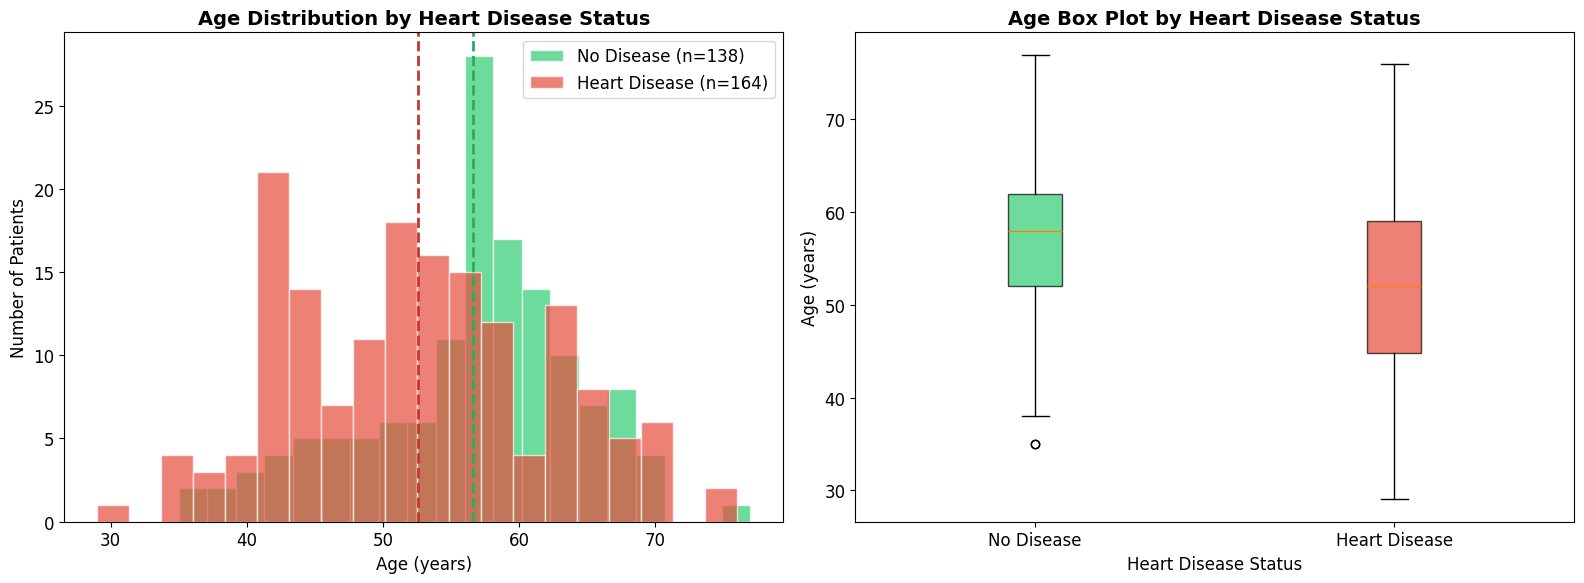

Age Statistics by Group:
        count   mean   std   min    25%   50%   75%   max
target                                                   
0       138.0  56.60  7.96  35.0  52.00  58.0  62.0  77.0
1       164.0  52.59  9.51  29.0  44.75  52.0  59.0  76.0


In [ ]:
# ============================================================
# CELL 7: Create Clean Working Copy
# ============================================================

# Make a clean copy to work with
# Always keep the original df unchanged — good practice!
df_clean = df.copy()

# Rename columns for clarity (optional but makes code more readable)
column_names = {
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'rest_ecg',
    'thalach': 'max_heart_rate',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'num_vessels',
    'thal': 'thalassemia'
}
df_clean = df_clean.rename(columns=column_names)

print("Clean dataset ready!")
print(f"Shape: {df_clean.shape}")
print("\nColumns:", df_clean.columns.tolist())
display(df_clean.head(3))

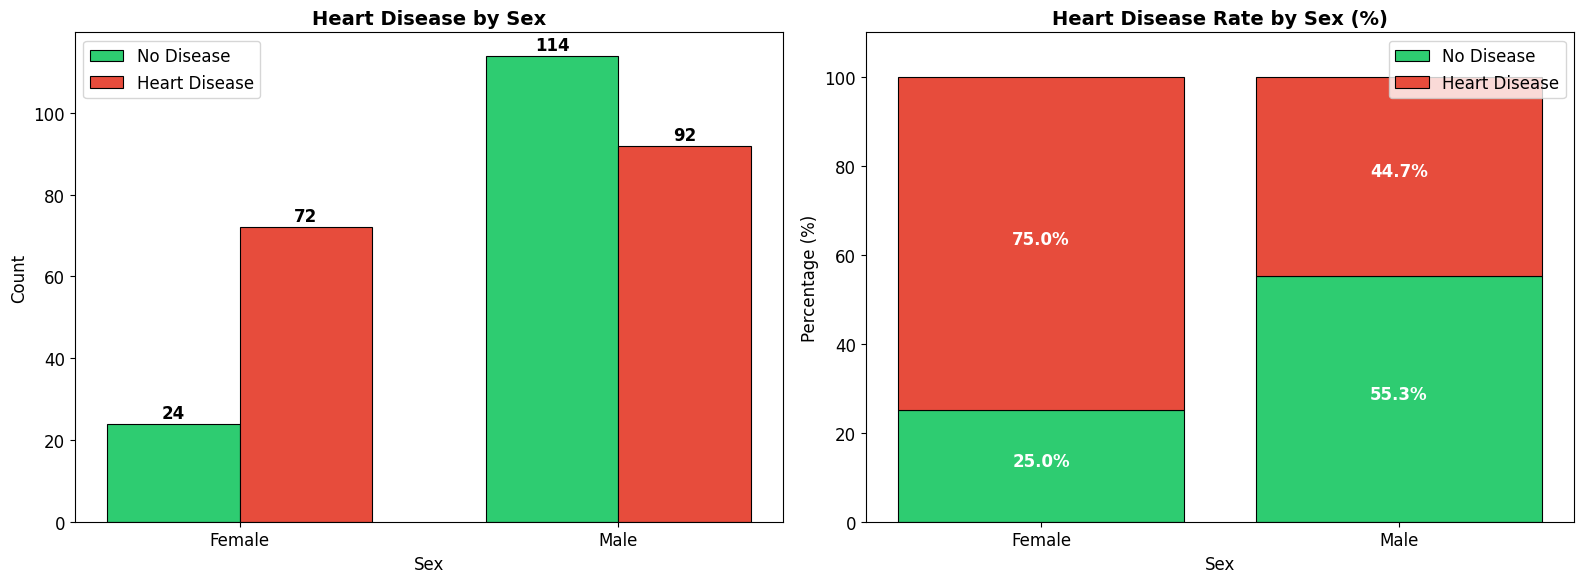

In [ ]:
# ============================================================
# CELL 8: Age Distribution vs Heart Disease
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram of age grouped by target
for target_val, color, label in [(0, '#2ecc71', 'No Disease'), (1, '#e74c3c', 'Heart Disease')]:
    subset = df_clean[df_clean['target'] == target_val]['age']
    axes[0].hist(
        subset,
        bins=20,
        alpha=0.7,
        color=color,
        label=f'{label} (n={len(subset)})',
        edgecolor='white'
    )

axes[0].set_title('Age Distribution by Heart Disease Status', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()
axes[0].axvline(df_clean[df_clean['target']==0]['age'].mean(), color='#27ae60', linestyle='--', linewidth=2, label='Mean (No Disease)')
axes[0].axvline(df_clean[df_clean['target']==1]['age'].mean(), color='#c0392b', linestyle='--', linewidth=2, label='Mean (Disease)')

# Right: Box plot
bp = axes[1].boxplot(
    [df_clean[df_clean['target']==0]['age'], df_clean[df_clean['target']==1]['age']],
    labels=['No Disease', 'Heart Disease'],
    patch_artist=True,
    notch=False
)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

axes[1].set_title('Age Box Plot by Heart Disease Status', fontweight='bold')
axes[1].set_ylabel('Age (years)')
axes[1].set_xlabel('Heart Disease Status')

plt.tight_layout()
plt.savefig('age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("Age Statistics by Group:")
print(df_clean.groupby('target')['age'].describe().round(2))

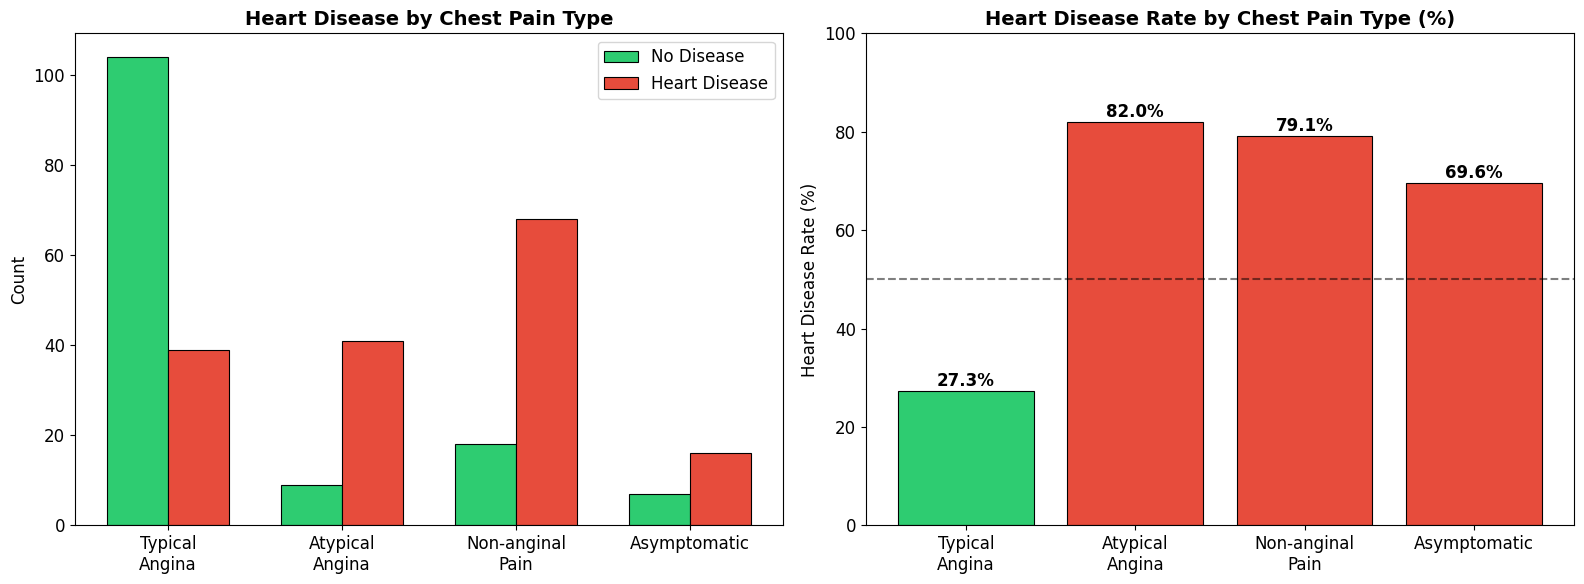


💡 Key Insight: Asymptomatic chest pain (type 3) has the highest heart disease rate.
   This seems counterintuitive but is a known medical phenomenon — called 'silent ischemia'.


In [11]:
# ============================================================
# CELL 9: Sex vs Heart Disease
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
sex_disease = df_clean.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_disease.index = ['Female', 'Male']
sex_disease.columns = ['No Disease', 'Heart Disease']

x = np.arange(len(sex_disease.index))
width = 0.35

bars1 = axes[0].bar(x - width/2, sex_disease['No Disease'], width, label='No Disease', 
                     color='#2ecc71', edgecolor='black', linewidth=0.8)
bars2 = axes[0].bar(x + width/2, sex_disease['Heart Disease'], width, label='Heart Disease', 
                     color='#e74c3c', edgecolor='black', linewidth=0.8)

axes[0].set_title('Heart Disease by Sex', fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Female', 'Male'])
axes[0].legend()

# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# Stacked percentage bar
sex_pct = sex_disease.div(sex_disease.sum(axis=1), axis=0) * 100
axes[1].bar(sex_pct.index, sex_pct['No Disease'], color='#2ecc71', label='No Disease', 
            edgecolor='black', linewidth=0.8)
axes[1].bar(sex_pct.index, sex_pct['Heart Disease'], bottom=sex_pct['No Disease'], 
            color='#e74c3c', label='Heart Disease', edgecolor='black', linewidth=0.8)

axes[1].set_title('Heart Disease Rate by Sex (%)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Sex')
axes[1].legend()
axes[1].set_ylim(0, 110)

for i, (idx, row) in enumerate(sex_pct.iterrows()):
    axes[1].text(i, row['No Disease']/2, f"{row['No Disease']:.1f}%", 
                 ha='center', fontweight='bold', color='white')
    axes[1].text(i, row['No Disease'] + row['Heart Disease']/2, f"{row['Heart Disease']:.1f}%", 
                 ha='center', fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('sex_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

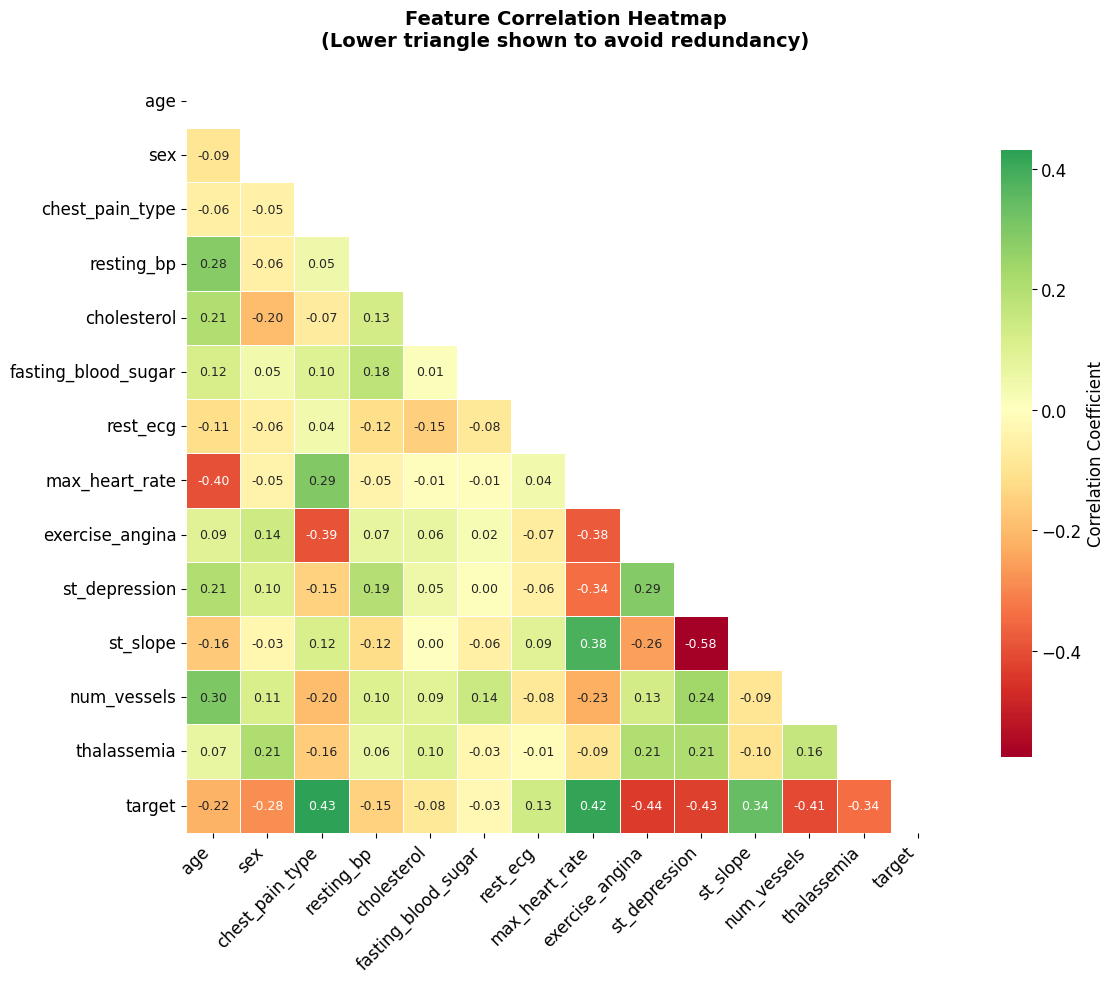


📊 Correlation with Target (Heart Disease):
  exercise_angina      -0.436  (↓ negative)
  chest_pain_type       0.432  (↑ positive)
  st_depression        -0.429  (↓ negative)
  max_heart_rate        0.420  (↑ positive)
  num_vessels          -0.409  (↓ negative)
  st_slope              0.344  (↑ positive)
  thalassemia          -0.343  (↓ negative)
  sex                  -0.284  (↓ negative)
  age                  -0.221  (↓ negative)
  resting_bp           -0.146  (↓ negative)
  rest_ecg              0.135  (↑ positive)
  cholesterol          -0.081  (↓ negative)
  fasting_blood_sugar  -0.027  (↓ negative)


In [12]:
# ============================================================
# CELL 10: Chest Pain Type vs Heart Disease
# ============================================================
# This is often one of the most important features in heart disease prediction

cp_labels = {
    0: 'Typical\nAngina',
    1: 'Atypical\nAngina', 
    2: 'Non-anginal\nPain',
    3: 'Asymptomatic'
}

df_clean['cp_label'] = df_clean['chest_pain_type'].map(cp_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
cp_disease = df_clean.groupby(['cp_label', 'target']).size().unstack(fill_value=0)
cp_disease.columns = ['No Disease', 'Heart Disease']

cp_order = ['Typical\nAngina', 'Atypical\nAngina', 'Non-anginal\nPain', 'Asymptomatic']
cp_disease = cp_disease.reindex(cp_order)

x = np.arange(len(cp_order))
width = 0.35

axes[0].bar(x - width/2, cp_disease['No Disease'], width, color='#2ecc71', 
            label='No Disease', edgecolor='black', linewidth=0.8)
axes[0].bar(x + width/2, cp_disease['Heart Disease'], width, color='#e74c3c', 
            label='Heart Disease', edgecolor='black', linewidth=0.8)

axes[0].set_title('Heart Disease by Chest Pain Type', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cp_order)
axes[0].set_ylabel('Count')
axes[0].legend()

# Disease rate per chest pain type
cp_rate = (cp_disease['Heart Disease'] / (cp_disease['No Disease'] + cp_disease['Heart Disease']) * 100)
colors = ['#e74c3c' if r > 50 else '#2ecc71' for r in cp_rate.values]
bars = axes[1].bar(cp_order, cp_rate.values, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Heart Disease Rate by Chest Pain Type (%)', fontweight='bold')
axes[1].set_ylabel('Heart Disease Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='black', linestyle='--', alpha=0.5, label='50% line')

for bar, val in zip(bars, cp_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chest_pain_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temp column
df_clean = df_clean.drop(columns=['cp_label'])

print("\nKey Insight: Asymptomatic chest pain (type 3) has the highest heart disease rate.")
print("   This seems counterintuitive but is a known medical phenomenon — called 'silent ischemia'.")

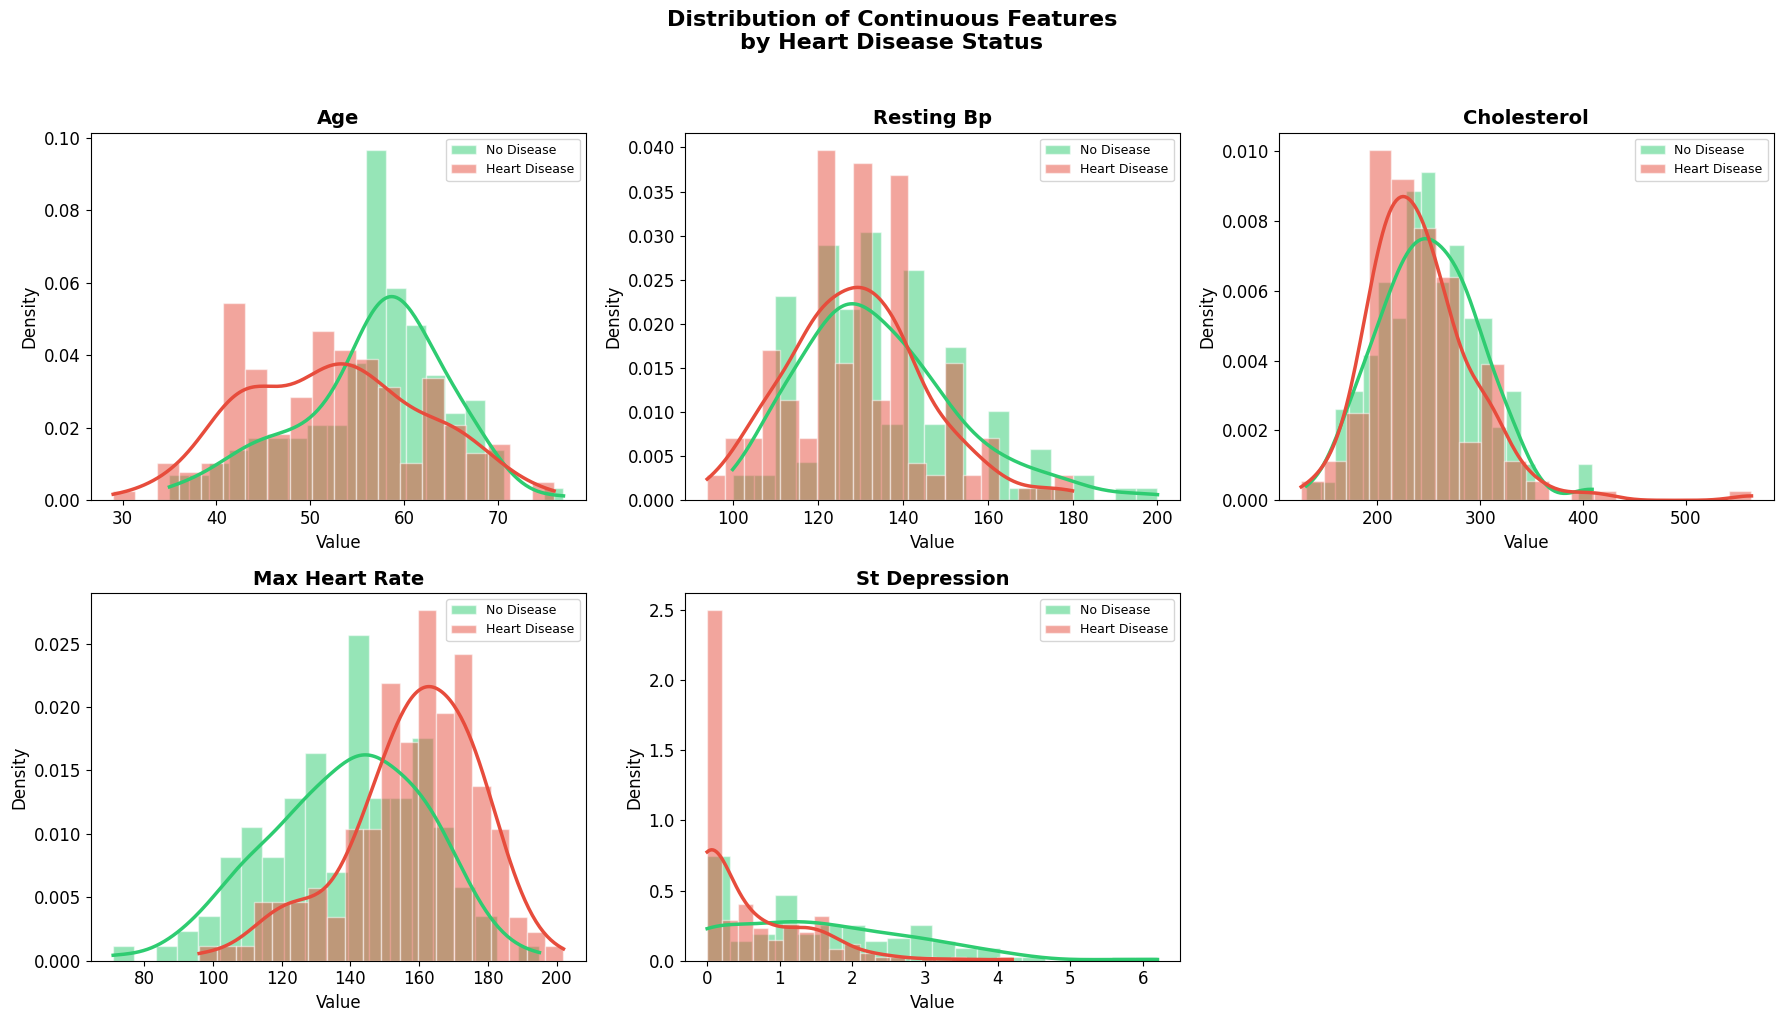

In [ ]:
# ============================================================
# CELL 11: Feature Correlation Heatmap
# ============================================================
# Correlation tells us how strongly two variables move together.
# Range: -1 (perfectly opposite) to +1 (perfectly same)
# 0 means no linear relationship

fig, ax = plt.subplots(figsize=(13, 10))

# Compute Pearson correlation matrix
corr_matrix = df_clean.drop(columns=['cp_label'], errors='ignore').corr()

# Create a mask for the upper triangle (redundant information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Show numbers in each cell
    fmt='.2f',           # 2 decimal places
    cmap='RdYlGn',       # Red (negative) → Yellow (zero) → Green (positive)
    center=0,            # Center colormap at 0
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Feature Correlation Heatmap\n(Lower triangle shown to avoid redundancy)', 
             fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with target specifically
print("\nCorrelations with Target (Heart Disease):")
print("=" * 45)
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    direction = "↑ positive" if val > 0 else "↓ negative"
    print(f"  {feat:<20} {val:>6.3f}  ({direction})")

In [14]:
# ============================================================
# CELL 12: Distribution of Continuous Features
# ============================================================

continuous_features = ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'st_depression']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    # KDE (Kernel Density Estimate) plot — smoother than histogram
    for target_val, color, label in [(0, '#2ecc71', 'No Disease'), (1, '#e74c3c', 'Heart Disease')]:
        subset = df_clean[df_clean['target'] == target_val][feature]
        axes[i].hist(subset, bins=20, alpha=0.5, color=color, label=label, density=True, edgecolor='white')
        
        # Add KDE line
        from scipy.stats import gaussian_kde
        if len(subset) > 1:
            kde = gaussian_kde(subset)
            x_range = np.linspace(subset.min(), subset.max(), 200)
            axes[i].plot(x_range, kde(x_range), color=color, linewidth=2.5)
    
    axes[i].set_title(f'{feature.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

# Hide the unused last subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Continuous Features\nby Heart Disease Status', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Features (X) shape: (302, 13)
Target (y) shape:   (302,)

Features used: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exercise_angina', 'st_depression', 'st_slope', 'num_vessels', 'thalassemia']

Target distribution:
target
1    164
0    138
Name: count, dtype: int64


In [15]:
# ============================================================
# CELL 13: Feature Selection and Target Separation
# ============================================================

# X = Features (inputs) — everything the model uses to make predictions
# y = Target (output) — what we're trying to predict

# Separate features and target
X = df_clean.drop(columns=['target'])
y = df_clean['target']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget distribution:\n{y.value_counts()}")

TRAIN-TEST SPLIT SUMMARY

Total samples:        302
Training samples:     241 (80%)
Testing samples:      61  (20%)

Training set class balance:
  No Disease: 110
  Disease:    131

Testing set class balance:
  No Disease: 28
  Disease:    33


In [16]:
# ============================================================
# CELL 14: Train-Test Split
# ============================================================
# Why split? If we train and test on the same data, the model just 
# "memorizes" it — like studying with the answer key. We need to
# test it on data it has NEVER seen before.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% for testing, 80% for training
    random_state=42,      # Makes results reproducible — same split every time
    stratify=y            # Ensures both train and test have similar class ratios
)

print("=" * 50)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 50)
print(f"\nTotal samples:        {len(X)}")
print(f"Training samples:     {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples:      {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")

print(f"\nTraining set class balance:")
print(f"  No Disease: {(y_train == 0).sum()}")
print(f"  Disease:    {(y_train == 1).sum()}")

print(f"\nTesting set class balance:")
print(f"  No Disease: {(y_test == 0).sum()}")
print(f"  Disease:    {(y_test == 1).sum()}")

✅ Feature scaling applied!

Before scaling — Training set statistics:
          age  cholesterol  max_heart_rate
count  241.00       241.00          241.00
mean    54.20       247.63          150.83
std      9.02        53.89           22.52
min     29.00       126.00           71.00
25%     47.00       211.00          138.00
50%     55.00       241.00          154.00
75%     60.00       277.00          167.00
max     77.00       564.00          202.00

After scaling — Training set statistics:
          age  cholesterol  max_heart_rate
count  241.00       241.00          241.00
mean    -0.00         0.00            0.00
std      1.00         1.00            1.00
min     -2.80        -2.26           -3.55
25%     -0.80        -0.68           -0.57
50%      0.09        -0.12            0.14
75%      0.64         0.55            0.72
max      2.53         5.88            2.28

  → Notice all means ≈ 0 and stds ≈ 1!


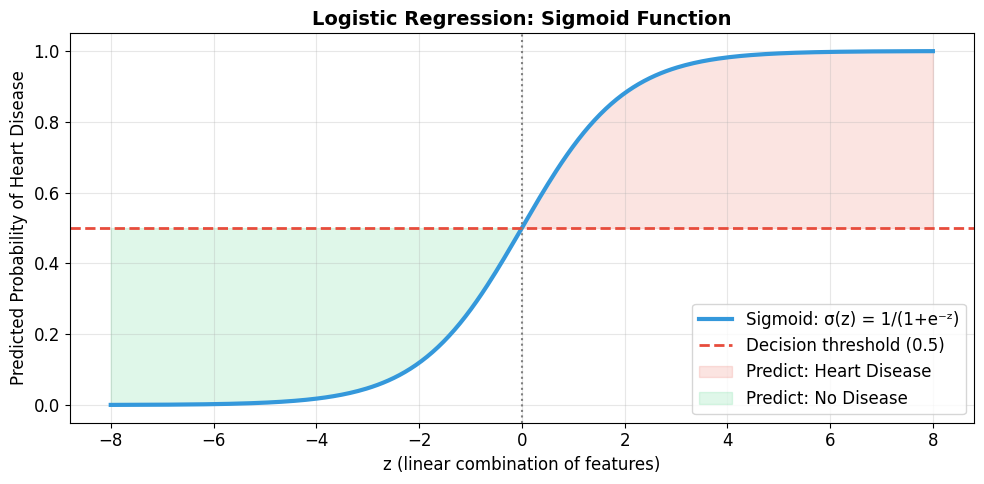

✅ Logistic Regression trained!

Model converged in 9 iterations
Number of features: 13


In [17]:
# ============================================================
# CELL 15: Feature Scaling with StandardScaler
# ============================================================
# 
# WHY SCALE?
# Age ranges from 29-77. Max heart rate from 71-202. Cholesterol from 126-564.
# If one feature has huge numbers, the model might think it's more important.
# Scaling puts all features on the same playing field.
#
# StandardScaler: Transforms each feature to have mean=0 and std=1
# Formula: z = (x - mean) / standard_deviation
#
# CRITICAL RULE: Fit on TRAINING data only, then transform BOTH.
# Fitting on test data would be "cheating" — it reveals info about the test set.

scaler = StandardScaler()

# Fit: Calculate mean and std from training data ONLY
# Transform: Apply the transformation
X_train_scaled = scaler.fit_transform(X_train)

# Transform: Use the SAME mean and std calculated from training data
X_test_scaled = scaler.transform(X_test)  # Note: only transform(), NOT fit_transform()

# Convert back to DataFrame for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Feature scaling applied!")
print("\nBefore scaling — Training set statistics:")
print(X_train[['age', 'cholesterol', 'max_heart_rate']].describe().round(2))

print("\nAfter scaling — Training set statistics:")
print(X_train_scaled_df[['age', 'cholesterol', 'max_heart_rate']].describe().round(2))
print("\n  → Notice all means ≈ 0 and stds ≈ 1!")

✅ Decision Tree trained!

Tree depth: 5
Number of leaves: 19
Number of nodes: 37


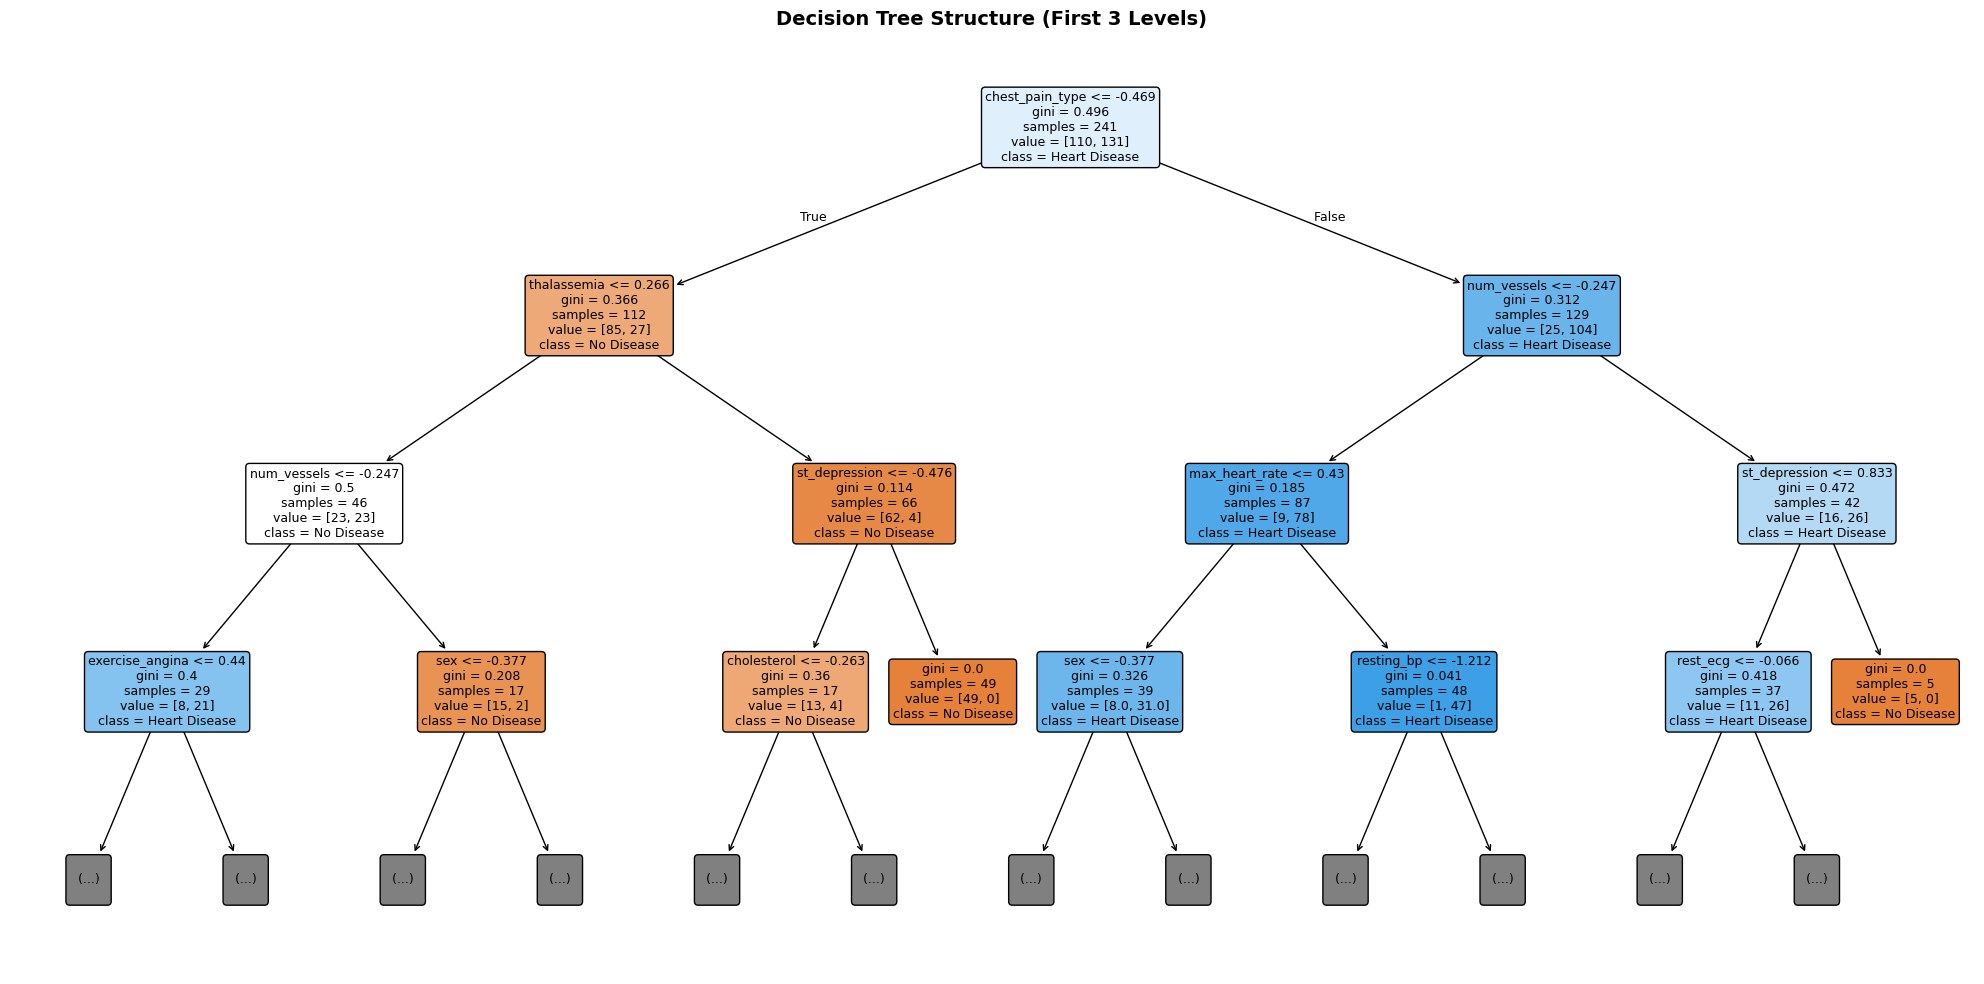


💡 Blue nodes → majority class is 'No Disease'
   Orange nodes → majority class is 'Heart Disease'
   Darker color → purer node (one class dominates more)


In [18]:
# ============================================================
# CELL 16: Logistic Regression — Theory and Training
# ============================================================
#
# WHAT IS LOGISTIC REGRESSION?
# Despite the name, it's a CLASSIFICATION algorithm, not regression.
# It predicts the PROBABILITY that a sample belongs to class 1.
#
# How it works:
# 1. Computes a linear combination: z = w1*age + w2*cholesterol + ... + b
# 2. Passes z through the SIGMOID function: P(disease) = 1 / (1 + e^(-z))
# 3. If P > 0.5 → predict Heart Disease (1)
# 4. If P ≤ 0.5 → predict No Disease (0)
#
# The sigmoid function squashes any real number to between 0 and 1.
# It gives us a probability — which is great for medical diagnosis!

# Visualize the Sigmoid Function
fig, ax = plt.subplots(figsize=(10, 5))
z_values = np.linspace(-8, 8, 300)
sigmoid_values = 1 / (1 + np.exp(-z_values))

ax.plot(z_values, sigmoid_values, color='#3498db', linewidth=3, label='Sigmoid: σ(z) = 1/(1+e⁻ᶻ)')
ax.axhline(0.5, color='#e74c3c', linestyle='--', linewidth=2, label='Decision threshold (0.5)')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.5)
ax.fill_between(z_values, sigmoid_values, 0.5, where=sigmoid_values > 0.5, 
                alpha=0.15, color='#e74c3c', label='Predict: Heart Disease')
ax.fill_between(z_values, sigmoid_values, 0.5, where=sigmoid_values < 0.5, 
                alpha=0.15, color='#2ecc71', label='Predict: No Disease')
ax.set_xlabel('z (linear combination of features)')
ax.set_ylabel('Predicted Probability of Heart Disease')
ax.set_title('Logistic Regression: Sigmoid Function', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sigmoid_function.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# Train Logistic Regression
# -------------------------------------------------------
lr_model = LogisticRegression(
    C=1.0,              # Regularization strength (higher C = less regularization)
    max_iter=1000,      # Maximum iterations for the solver to converge
    random_state=42,
    solver='lbfgs'      # Optimization algorithm (L-BFGS works well for small datasets)
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained!")
print(f"\nModel converged in {lr_model.n_iter_[0]} iterations")
print(f"Number of features: {lr_model.n_features_in_}")

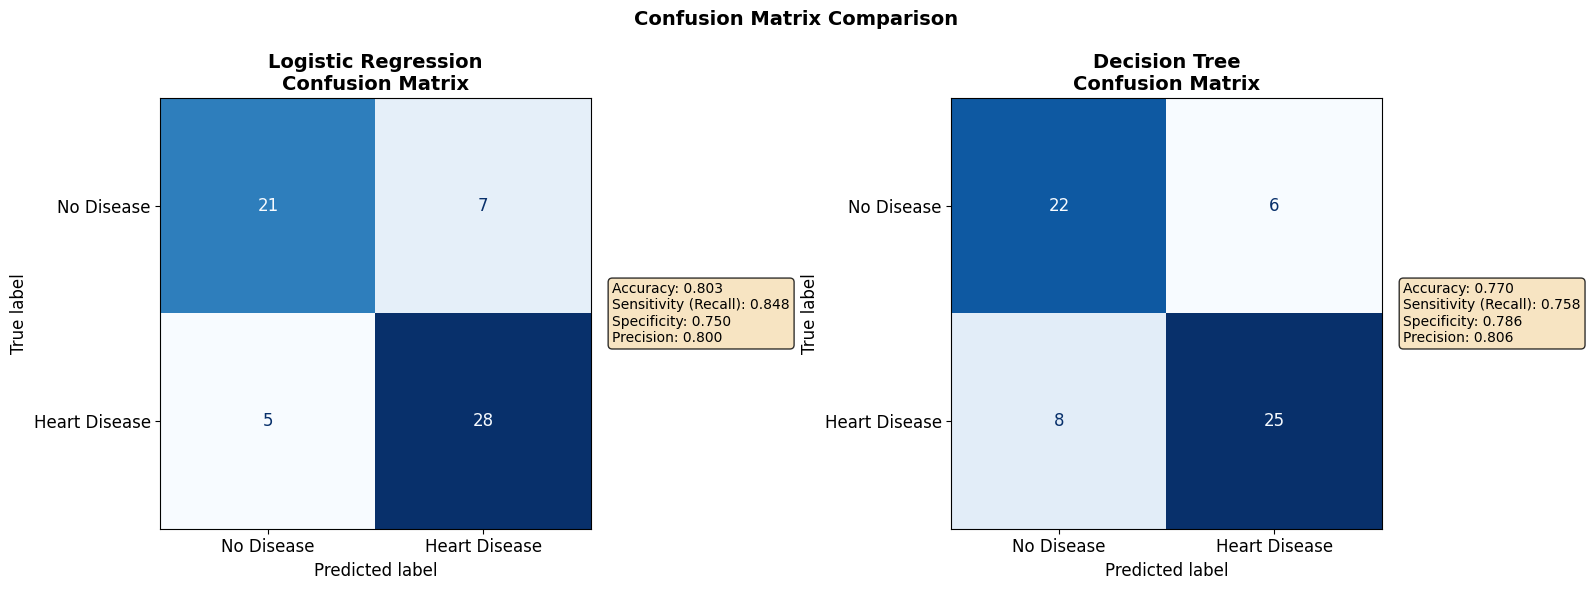

In [19]:
# ============================================================
# CELL 17: Decision Tree — Theory and Training
# ============================================================
#
# WHAT IS A DECISION TREE?
# It mimics how a doctor might think:
# "Is age > 55? → If yes, is cholesterol > 240? → If yes, predict DISEASE..."
#
# The algorithm learns these rules automatically from data!
#
# Key concepts:
# - ROOT NODE: The first question asked (most informative feature)
# - LEAF NODES: Final predictions at the end of branches
# - DEPTH: How many questions deep the tree goes
# - GINI IMPURITY: Measures how "mixed" a node is (0=pure, 0.5=perfectly mixed)
#
# Decision Trees DON'T need feature scaling (they use thresholds, not distances)
# But we'll train on both scaled and unscaled for consistency

dt_model = DecisionTreeClassifier(
    max_depth=5,            # Maximum depth of the tree (prevents overfitting)
    min_samples_split=10,   # Minimum samples required to split a node
    min_samples_leaf=5,     # Minimum samples required in a leaf node
    criterion='gini',       # Use Gini impurity to measure split quality
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

print("Decision Tree trained!")
print(f"\nTree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")
print(f"Number of nodes: {dt_model.tree_.node_count}")

# Visualize the tree structure (first 3 levels)
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,            # Only show first 3 levels for readability
    feature_names=X_train.columns.tolist(),
    class_names=['No Disease', 'Heart Disease'],
    filled=True,            # Color nodes by majority class
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree Structure (First 3 Levels)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBlue nodes → majority class is 'No Disease'")
print("   Orange nodes → majority class is 'Heart Disease'")
print("   Darker color → purer node (one class dominates more)")

In [20]:
# ============================================================
# CELL 18: Confusion Matrix
# ============================================================
#
# WHAT IS A CONFUSION MATRIX?
# A 2×2 table showing:
#
#                   Predicted NO    Predicted YES
# Actual NO      |  True Negative  | False Positive |
# Actual YES     |  False Negative | True Positive  |
#
# TRUE POSITIVE  (TP): Model said Disease, Patient has Disease ✅
# TRUE NEGATIVE  (TN): Model said No Disease, Patient has No Disease ✅
# FALSE POSITIVE (FP): Model said Disease, Patient is Healthy ❌ (Type I Error)
# FALSE NEGATIVE (FN): Model said No Disease, Patient has Disease ❌ (Type II Error)
#
# In medical diagnosis, FALSE NEGATIVES ARE DANGEROUS.
# Missing a heart disease patient is worse than flagging a healthy one.
# This is why we need more than just accuracy!

# Get predictions
lr_predictions = lr_model.predict(X_test_scaled)
dt_predictions = dt_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_pred, model_name in [
    (axes[0], lr_predictions, 'Logistic Regression'),
    (axes[1], dt_predictions, 'Decision Tree')
]:
    cm = confusion_matrix(y_test, model_pred)
    
    # Manual colored display for better insight
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Disease', 'Heart Disease']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    
    # Add metric annotations
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)  # Also called Recall
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    
    metrics_text = (
        f'Accuracy: {accuracy:.3f}\n'
        f'Sensitivity (Recall): {sensitivity:.3f}\n'
        f'Specificity: {specificity:.3f}\n'
        f'Precision: {precision:.3f}'
    )
    ax.text(1.05, 0.5, metrics_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


CLASSIFICATION REPORT: Logistic Regression
               precision    recall  f1-score   support

   No Disease     0.8077    0.7500    0.7778        28
Heart Disease     0.8000    0.8485    0.8235        33

     accuracy                         0.8033        61
    macro avg     0.8038    0.7992    0.8007        61
 weighted avg     0.8035    0.8033    0.8025        61


CLASSIFICATION REPORT: Decision Tree
               precision    recall  f1-score   support

   No Disease     0.7333    0.7857    0.7586        28
Heart Disease     0.8065    0.7576    0.7812        33

     accuracy                         0.7705        61
    macro avg     0.7699    0.7716    0.7699        61
 weighted avg     0.7729    0.7705    0.7709        61



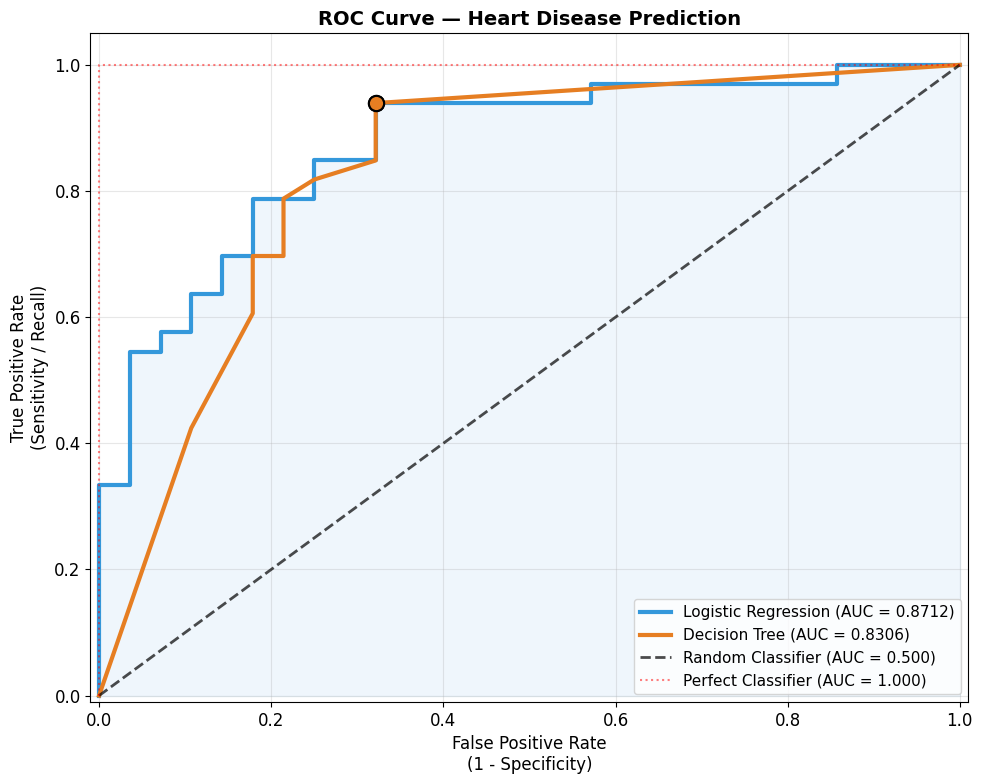

In [21]:
# ============================================================
# CELL 19: Full Classification Reports
# ============================================================
#
# METRIC DEFINITIONS:
#
# PRECISION:    Of all patients we predicted have disease, what % actually do?
#               = TP / (TP + FP)
#               High precision = few false alarms
#
# RECALL:       Of all patients who actually have disease, what % did we catch?
#               = TP / (TP + FN)
#               High recall = few missed cases (critical for medical!)
#
# F1-SCORE:     Harmonic mean of Precision and Recall
#               = 2 * (Precision * Recall) / (Precision + Recall)
#               Balances both — use when you care about both
#
# SUPPORT:      Number of actual samples in that class

for model_pred, model_name in [
    (lr_predictions, 'Logistic Regression'),
    (dt_predictions, 'Decision Tree')
]:
    print(f"\n{'='*60}")
    print(f"CLASSIFICATION REPORT: {model_name}")
    print(f"{'='*60}")
    print(classification_report(
        y_test, model_pred,
        target_names=['No Disease', 'Heart Disease'],
        digits=4
    ))

In [22]:
# ============================================================
# CELL 20: ROC Curve and AUC Score
# ============================================================
#
# WHAT IS ROC?
# ROC = Receiver Operating Characteristic curve
#
# It plots:
# - X-axis: False Positive Rate (FPR) = FP / (FP + TN) — how often do we raise false alarms?
# - Y-axis: True Positive Rate (TPR) = TP / (TP + FN) — how often do we catch real cases?
#
# WHAT IS AUC?
# AUC = Area Under the ROC Curve
# Range: 0.5 to 1.0
# - 0.5 = Random guessing (useless model)
# - 0.7-0.8 = Fair
# - 0.8-0.9 = Good
# - 0.9-1.0 = Excellent
# - 1.0 = Perfect (suspicious — might be overfitting!)
#
# The diagonal line represents a RANDOM classifier.
# A better model pushes the curve toward the TOP-LEFT corner.

fig, ax = plt.subplots(figsize=(10, 8))

# Get probability scores (not just 0/1 predictions)
# predict_proba() gives [P(class=0), P(class=1)]
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of Disease
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC for each model
for proba, label, color in [
    (lr_proba, 'Logistic Regression', '#3498db'),
    (dt_proba, 'Decision Tree', '#e67e22')
]:
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=3, 
            label=f'{label} (AUC = {roc_auc:.4f})')
    
    # Mark the optimal threshold point (maximizes TPR - FPR)
    optimal_idx = np.argmax(tpr - fpr)
    ax.scatter(fpr[optimal_idx], tpr[optimal_idx], s=120, color=color, 
               zorder=5, edgecolors='black', linewidth=1.5)

# Random classifier (baseline)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.7, label='Random Classifier (AUC = 0.500)')

# Perfect classifier
ax.plot([0, 0, 1], [0, 1, 1], ':r', linewidth=1.5, alpha=0.5, label='Perfect Classifier (AUC = 1.000)')

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel('False Positive Rate\n(1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate\n(Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curve — Heart Disease Prediction', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL PERFORMANCE COMPARISON


,Logistic Regression,Decision Tree
Accuracy,0.8033,0.7705
Precision,0.8000,0.8065
Recall,0.8485,0.7576
F1-Score,0.8235,0.7812
ROC-AUC,0.8712,0.8306
Specificity,0.7500,0.7857
TP,28.0000,25.0000
TN,21.0000,22.0000
FP,7.0000,6.0000
FN,5.0000,8.0000



💡 INTERPRETATION GUIDE:
  → Higher is better for all metrics except FP and FN
  → For medical use: prioritize RECALL (don't miss sick patients)
  → ROC-AUC > 0.8 is generally considered 'good'


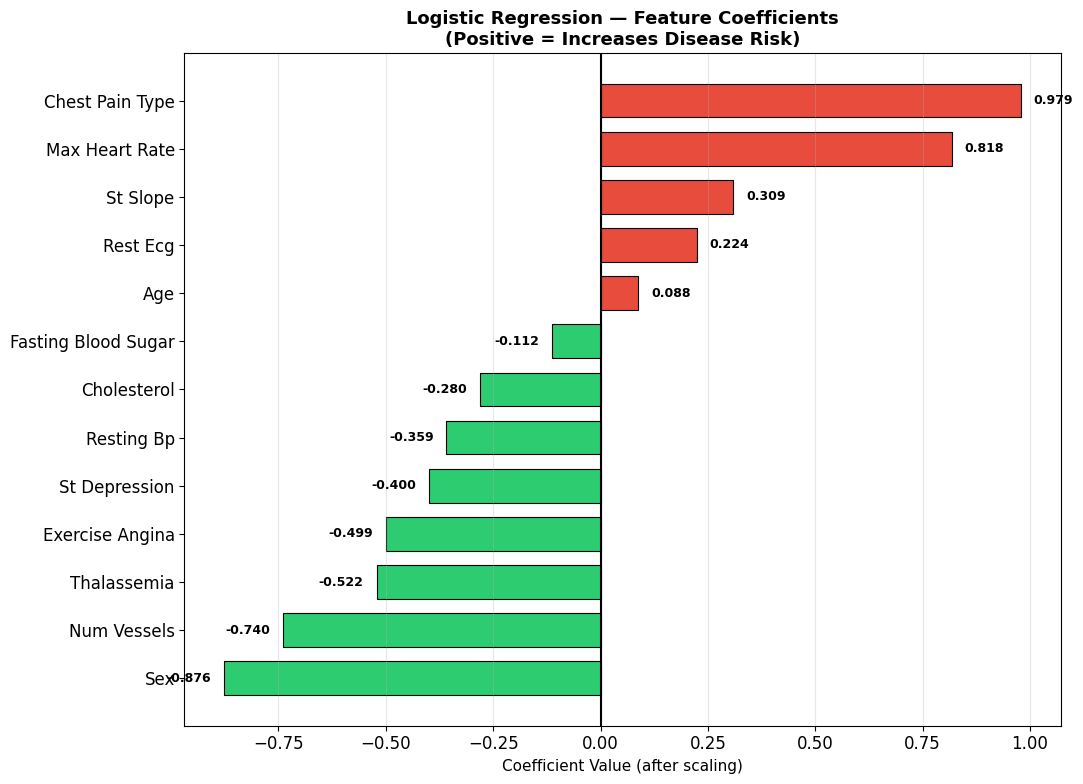

In [23]:
# ============================================================
# CELL 21: Model Performance Summary
# ============================================================

from sklearn.metrics import (roc_auc_score, f1_score, 
                              precision_score, recall_score)

def get_metrics(y_true, y_pred, y_proba):
    """Calculate a comprehensive set of evaluation metrics."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy':    accuracy_score(y_true, y_pred),
        'Precision':   precision_score(y_true, y_pred),
        'Recall':      recall_score(y_true, y_pred),
        'F1-Score':    f1_score(y_true, y_pred),
        'ROC-AUC':     roc_auc_score(y_true, y_proba),
        'Specificity': tn / (tn + fp),
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

lr_metrics = get_metrics(y_test, lr_predictions, lr_proba)
dt_metrics = get_metrics(y_test, dt_predictions, dt_proba)

# Display comparison
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Decision Tree': dt_metrics
})

print("=" * 55)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 55)
display(comparison_df.style
        .format('{:.4f}', subset=['Logistic Regression', 'Decision Tree'], 
                na_rep='-')
        .background_gradient(cmap='RdYlGn', axis=1, subset=pd.IndexSlice[
            ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Specificity'], :
        ]))

print("\nINTERPRETATION GUIDE:")
print("  → Higher is better for all metrics except FP and FN")
print("  → For medical use: prioritize RECALL (don't miss sick patients)")
print("  → ROC-AUC > 0.8 is generally considered 'good'")

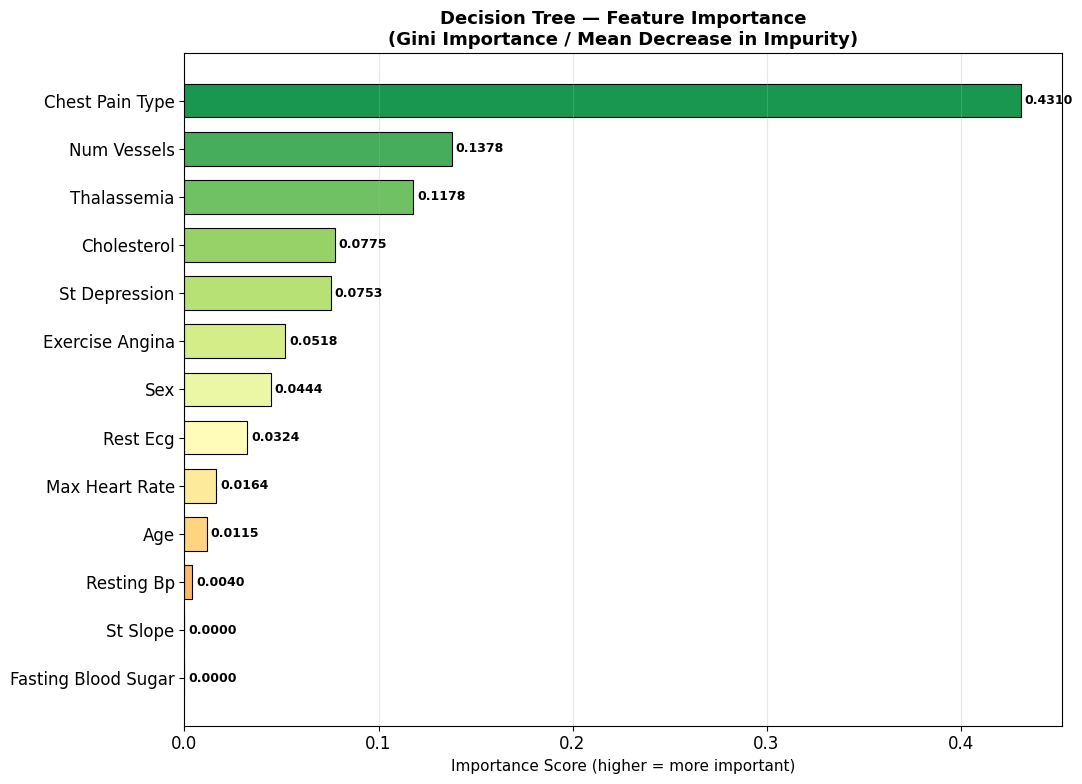

In [24]:
# ============================================================
# CELL 23: Feature Importance — Decision Tree
# ============================================================
#
# Decision Trees have a built-in feature_importances_ attribute.
# This measures how much each feature REDUCES impurity when used for splitting.
# Range: 0 to 1, and all importances sum to 1.
#
# This is called GINI IMPORTANCE or MEAN DECREASE IN IMPURITY.

dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Color gradient
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(dt_importance)))

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    dt_importance['Feature'].str.replace('_', ' ').str.title(),
    dt_importance['Importance'],
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    height=0.7
)

ax.set_title('Decision Tree — Feature Importance\n(Gini Importance / Mean Decrease in Impurity)', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score (higher = more important)', fontsize=11)

for bar, val in zip(bars, dt_importance['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

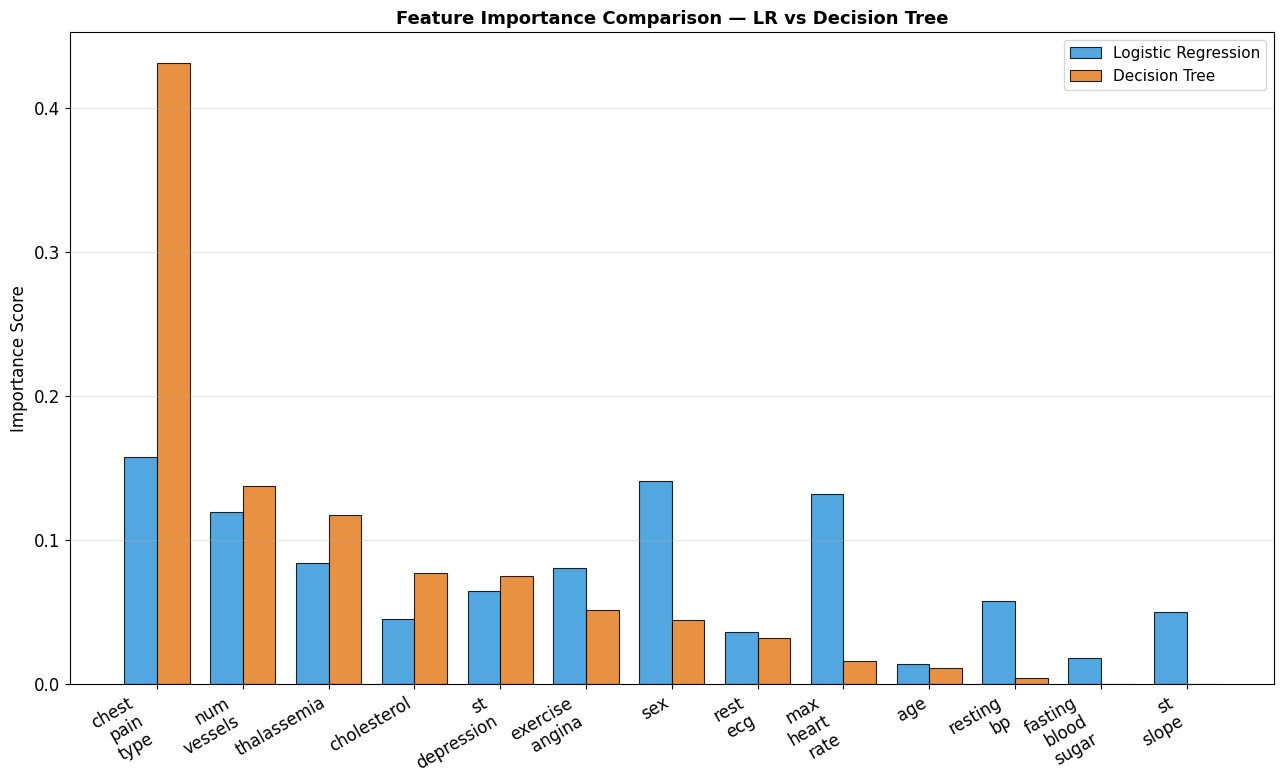


🏆 TOP 5 FEATURES BY EACH MODEL:

Logistic Regression (by absolute coefficient):
  1. chest_pain_type           0.1577
  2. sex                       0.1412
  3. max_heart_rate            0.1318
  4. num_vessels               0.1193
  5. thalassemia               0.0840

Decision Tree (by Gini importance):
  1. chest_pain_type           0.4310
  2. num_vessels               0.1378
  3. thalassemia               0.1178
  4. cholesterol               0.0775
  5. st_depression             0.0753


In [25]:
# ============================================================
# CELL 24: Combined Feature Importance — Both Models
# ============================================================

# Normalize LR coefficients to [0,1] range for comparison
lr_abs_normalized = np.abs(lr_coef.set_index('Feature')['Coefficient'])
lr_abs_normalized = lr_abs_normalized / lr_abs_normalized.sum()

dt_imp = dt_importance.set_index('Feature')['Importance']

# Combine into one DataFrame
combined = pd.DataFrame({
    'Logistic Regression\n(Normalized |Coeff|)': lr_abs_normalized,
    'Decision Tree\n(Gini Importance)': dt_imp
}).sort_values('Decision Tree\n(Gini Importance)', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))

x = np.arange(len(combined))
width = 0.38

ax.bar(x - width/2, combined['Logistic Regression\n(Normalized |Coeff|)'], 
       width, label='Logistic Regression', color='#3498db', edgecolor='black', linewidth=0.8, alpha=0.85)
ax.bar(x + width/2, combined['Decision Tree\n(Gini Importance)'], 
       width, label='Decision Tree', color='#e67e22', edgecolor='black', linewidth=0.8, alpha=0.85)

ax.set_title('Feature Importance Comparison — LR vs Decision Tree', fontweight='bold', fontsize=13)
ax.set_ylabel('Importance Score')
ax.set_xticks(x)
ax.set_xticklabels(
    [f.replace('_', '\n') for f in combined.index],
    rotation=30, ha='right'
)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('combined_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features by both models
print("\nTOP 5 FEATURES BY EACH MODEL:")
print("\nLogistic Regression (by absolute coefficient):")
top_lr = lr_abs_normalized.sort_values(ascending=False).head(5)
for i, (feat, val) in enumerate(top_lr.items(), 1):
    print(f"  {i}. {feat:<25} {val:.4f}")

print("\nDecision Tree (by Gini importance):")
top_dt = dt_imp.sort_values(ascending=False).head(5)
for i, (feat, val) in enumerate(top_dt.items(), 1):
    print(f"  {i}. {feat:<25} {val:.4f}")

In [ ]:
# ============================================================
# CELL 25: Final Results Summary
# ============================================================

print("=" * 70)
print("   HEART DISEASE PREDICTION — FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"""
DATASET
   Source:     UCI Heart Disease Dataset (Cleveland)
   Samples:    {len(df_clean)} patients
   Features:   {len(X.columns)} health indicators
   Target:     Binary (0 = No Disease, 1 = Heart Disease)

MODELS TRAINED
   1. Logistic Regression  (max_iter=1000, C=1.0)
   2. Decision Tree        (max_depth=5, min_samples_leaf=5)

PERFORMANCE COMPARISON
   ┌─────────────────────┬────────────────────┬───────────────┐
   │ Metric              │ Logistic Regression│ Decision Tree │
   ├─────────────────────┼────────────────────┼───────────────┤
   │ Accuracy            │ {lr_metrics['Accuracy']:.4f}             │ {dt_metrics['Accuracy']:.4f}        │
   │ Precision           │ {lr_metrics['Precision']:.4f}             │ {dt_metrics['Precision']:.4f}        │
   │ Recall (Sensitivity)│ {lr_metrics['Recall']:.4f}             │ {dt_metrics['Recall']:.4f}        │
   │ F1-Score            │ {lr_metrics['F1-Score']:.4f}             │ {dt_metrics['F1-Score']:.4f}        │
   │ ROC-AUC             │ {lr_metrics['ROC-AUC']:.4f}             │ {dt_metrics['ROC-AUC']:.4f}        │
   └─────────────────────┴────────────────────┴───────────────┘

KEY MEDICAL FEATURES (from both models)
   The features most strongly associated with heart disease risk:
   1. chest_pain_type   — Asymptomatic pain has highest disease rate
   2. max_heart_rate    — Lower max HR during exercise → higher risk
   3. st_depression     — Higher ST depression → higher risk
   4. num_vessels       — More blocked vessels → more risk
   5. thalassemia       — Reversible defect type → higher risk

RECOMMENDATION
   {'Logistic Regression' if lr_metrics['ROC-AUC'] >= dt_metrics['ROC-AUC'] else 'Decision Tree'} is the better model for this dataset
   (higher ROC-AUC of {max(lr_metrics['ROC-AUC'], dt_metrics['ROC-AUC']):.4f})
   
   However, for medical deployment, consider:
   → Ensemble methods (Random Forest, XGBoost) for better accuracy
   → External validation on a new hospital's data
   → Clinical review of false negatives before deployment
""")

   HEART DISEASE PREDICTION — FINAL PROJECT SUMMARY

📊 DATASET
   Source:     UCI Heart Disease Dataset (Cleveland)
   Samples:    302 patients
   Features:   13 health indicators
   Target:     Binary (0 = No Disease, 1 = Heart Disease)

🤖 MODELS TRAINED
   1. Logistic Regression  (max_iter=1000, C=1.0)
   2. Decision Tree        (max_depth=5, min_samples_leaf=5)

📈 PERFORMANCE COMPARISON
   ┌─────────────────────┬────────────────────┬───────────────┐
   │ Metric              │ Logistic Regression│ Decision Tree │
   ├─────────────────────┼────────────────────┼───────────────┤
   │ Accuracy            │ 0.8033             │ 0.7705        │
   │ Precision           │ 0.8000             │ 0.8065        │
   │ Recall (Sensitivity)│ 0.8485             │ 0.7576        │
   │ F1-Score            │ 0.8235             │ 0.7812        │
   │ ROC-AUC             │ 0.8712             │ 0.8306        │
   └─────────────────────┴────────────────────┴───────────────┘

🔑 KEY MEDICAL FEATURES (from b